# MACHINE LEARNING
# Feature Selection

First, we load the required packages.

In [2]:
from sklearn.model_selection import RepeatedKFold, GridSearchCV, train_test_split, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.base import BaseEstimator
from sklearn.base import TransformerMixin
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
import sys
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn import preprocessing
warnings.filterwarnings("ignore")

#### Loading the Data

The dataset considered is a prostate dataset from the reference: ['Gene expression correlates of clinical prostate cancer behavior'](https://www.cell.com/cancer-cell/fulltext/S1535-6108(02)00030-2?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS1535610802000302%3Fshowall%3Dtrue).

In [3]:
dataprostate = pd.read_csv('prostate.csv')
print(dataprostate.shape)

y = (dataprostate.values[ :, -1]).astype(int) # Taking the last column
X = dataprostate.values[ :, :-1].astype(float) # Removing the last column

print(y.shape)
print(X.shape)

(102, 12626)
(102,)
(102, 12625)


This dataset consists of 102 instances of prostate samples, and 12,626 attributes (genes). There are two classes, tumour and non tumour.

### Questions to address

**1. Estimate the performance** of the nearest neighbor classifier on this dataset **using 10-times 10-fold cross validation when all the features are used for prediction**. The number of neighbors should be chosen using an inner cross-validation procedure. You can use 5-fold cross validation for this.

In [4]:
# External Cross Validation Process to Estimate the Generalization Performance
ext_cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=0) # 10-times 10-fold CV

In [7]:
%%time

# Defining the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),   # normalization
    ('knn', KNeighborsClassifier())
])

# Hyperparameter search space
param_grid = {'knn__n_neighbors': np.arange(1, 21)}  # Try between 1-20

# Store results
ext_scores = []

for train_idx, test_idx in ext_cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Hyperparameter search
    inner_cv = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy') # 5-fold CV
    inner_cv.fit(X_train, y_train)
    
    # Evaluate best model
    best_model = inner_cv.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ext_scores.append(acc)

CPU times: total: 1min 10s
Wall time: 3min 48s


In [8]:
# Results
print(f"Mean Accuracy: {np.mean(ext_scores):.4f}")
print(f"Std Accuracy: {np.std(ext_scores):.4f}")

Mean Accuracy: 0.7932
Std Accuracy: 0.1298


- The expected performance of the model is rather low, around 80%. Furthermore, the model is not too stable, since the standard deviation is around 13%, which means that the performance of the model varies quite a lot with the training and testing splits done.

**2. Estimate the performance** of the nearest neighbor classifier on the same dataset **when using a feature selection technique based on the F-score (ANOVA)** that picks up the 10 most relevant features. Use the same cross-validation methods as in the previous step.

In [9]:
%%time

# Defining the pipeline
pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)), # f-score selection
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Hyperparameter search space
param_grid = {'knn__n_neighbors': np.arange(1, 21)}

# Store results
ext_select_scores = []

for train_idx, test_idx in ext_cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Hyperparameter search
    inner_cv = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
    inner_cv.fit(X_train, y_train)
    
    # Evaluate best model
    best_model = inner_cv.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ext_select_scores.append(acc)

CPU times: total: 2min 29s
Wall time: 5min 3s


In [11]:
# Results
print(f"Mean Accuracy after feature selection: {np.mean(ext_select_scores):.4f}")
print(f"Std Accuracy after feature selection: {np.std(ext_select_scores):.4f}")

Mean Accuracy after feature selection: 0.9129
Std Accuracy after feature selection: 0.0991


- After feature selection, the accuracy is ~91% and the variability in accuracy is ~0.1%.

**3. Repeat** the previous experiment but **when a random forest is used to pick up the 10 most relevant features**. Use an **initial filtering method based on the F-score to keep** only the **20%** most promising features.

In [10]:
%%time

# k20 = 20% of attributes
k20 = int(round(X.shape[1] * 0.20))

# Defining the pipeline
pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_classif, k=k20)), # f-score selection (20%)
    ('RF', SelectFromModel(RandomForestClassifier(n_estimators=101, random_state=0),
                           max_features=10, threshold=-np.inf)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Hyperparameter search space
param_grid = {'knn__n_neighbors': np.arange(1, 21)}

# Store results
ext_selectRF_scores = []

for train_idx, test_idx in ext_cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Hyperparameter search
    inner_cv = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
    inner_cv.fit(X_train, y_train)
    
    # Evaluate best model
    best_model = inner_cv.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ext_selectRF_scores.append(acc)

CPU times: total: 19min
Wall time: 40min 41s


In [14]:
# Results
print(f"Mean Accuracy after feature filtering (20%) and selection with Random Forest: {np.mean(ext_selectRF_scores):.4f}")
print(f"Std Accuracy after feature filtering (20%) and selection with Random Forest: {np.std(ext_selectRF_scores):.4f}")

Mean Accuracy after feature filtering (20%) and selection with Random Forest: 0.9055
Std Accuracy after feature filtering (20%) and selection with Random Forest: 0.0929



**4. What feature selection method performs best?** Can you explain **why?**

The following is a comparative table for all the methods used:

In [43]:
score_list = [ext_scores, ext_select_scores, ext_selectRF_scores]

methods = [
    "kNN All Features",
    "ANOVA 10 Features",
    "20% ANOVA + RF"
]

# Table header
print("Method \t \t \t Accuracy \t Error Rate")
print("----------------------------------------------------")

for method, scores in zip(methods, score_list):
    accuracy = np.mean(scores)
    error_rate = (1 - accuracy) * 100
    print(f"{method}   \t {accuracy:.4f} \t {error_rate:6.2f}%")

Method 	 	 	 Accuracy 	 Error Rate
----------------------------------------------------
kNN All Features   	 0.7932 	  20.68%
ANOVA 10 Features   	 0.9129 	   8.71%
20% ANOVA + RF   	 0.9055 	   9.45%


- We used two different feature selection methods, first feature selection alone (F-score only) and then feature selection to filter 20% of features followed by Random Forest (RF). The feature selection method alone performed better than in combination with Random Forest.
- The reason for this could be due to the fact that feature selection is an univariate method, which selects features that maximize class separation individually. Whilst random forest is multivariate, where feature importance are considered in correlation. Feature selection alone is selecting 10 variables purely maximizing discrimination. Whilst by filtering first with 20% feature selection and then using RF, although we reduce computational cost, we might be keeping redundant or correlated features instead of the truly most informative ones, and RF may be prioritizing correlated features, even if they are redundant. Which results in that feature selection alone gives slightly better generalization on this dataset.
- Generally for high dimensional datasets feature selection works better, whilst random forest tends to overfit when there are too many irrelevant or correlated features.

#### Now we will address the problem of analyzing the **trade-off between interpretability and prediction accuracy**. For this, you are asked to:
<!-- Nos comento en clase que digamos que ocurre con el error de generalizacion sesgado. -->

**1. Estimate the performance** of the nearest neighbor classifier with **K=3** as a function of the features used for prediction. 

- Use a 10-times 10-fold cross-validation method and **plot the results obtained**. That is prediction error vs. the number of features used for prediction. 
- Use the F-score for feature selection. 
- Report results from 1 feature to 200 features. Not all features need to be explored. 
- Use a higher resolution when you are closer to 1 feature.

<br>
We are going to see the dependence of the error to the number of attributes chosen. To do this, we are going to use 10-times 10-fold 
validation using KNN with k=3 and using the F-statistic to select the attributes.

In [4]:
scaler = StandardScaler()
knn = KNeighborsClassifier(n_neighbors=3)

# 10-Fold 10_cross validation
rkf = RepeatedKFold(n_splits=10, n_repeats = 10, random_state=0)

# Select 200 attributes with a higher resolution in the first attributes
n_features = np.unique(np.round(np.exp(np.arange(0, np.log(200), 0.1))).astype(int))

errors_knn = np.zeros((10 * 10, len(n_features)))

split = 0

for train_index, test_index in rkf.split(X, y):

    # Train / test partition
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Standardize the data
    scaler.fit(X_train, y_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    # Loop over the number of features to be tested
    for i in range(len(n_features)):
        
        # Create a filter to select the required number of features based on the F-statistic
        filtering = SelectKBest(f_classif, k = n_features[ len(n_features) - i - 1 ])
        filtering.fit(X_train, y_train)
        
        # Carry out the feature selection process
        X_train_sel = filtering.transform(X_train)
        X_test_sel = filtering.transform(X_test)

        # Fit the classifier on the training data and evaluate its performance on test data
        knn.fit(X_train_sel, y_train)
        errors_knn[ split, len(n_features) - i - 1 ] = 1.0 - np.mean(knn.predict(X_test_sel) == y_test)
        
    split += 1

# Compute mean errors and the corresponding standard deviations
error = np.mean(errors_knn, 0)
error_std = np.std(errors_knn, 0) / np.sqrt(errors_knn.shape[ 0 ])

Now let's plot the results.

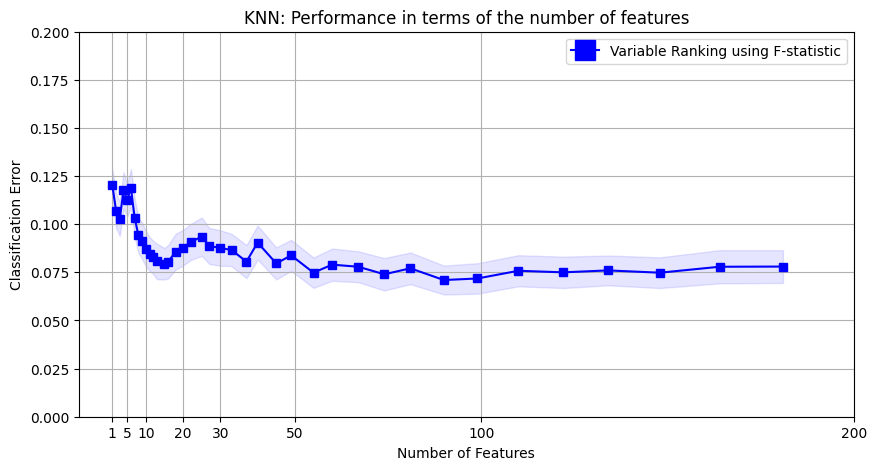

In [45]:
sel = np.arange(1, len(n_features) + 1, 8) - 1

plt.figure(figsize=(10,5))
line1, = plt.plot(n_features, error, 's-', color="b")
plt.fill_between(n_features, error - error_std, error + error_std, alpha=0.1, color="b")
plt.grid()
plt.title("KNN: Performance in terms of the number of features")
plt.xlabel('Number of Features')
plt.xticks(np.array([1, 5, 10, 20, 30, 50, 100, 200]))
plt.ylabel('Classification Error')
plt.ylim(0.0,  0.2)
legend_handles = [ mlines.Line2D([], [], color='b', marker='s', \
    markersize=15, label='Variable Ranking using F-statistic')]
plt.legend(handles=legend_handles, loc = 1)
plt.show()

**2. Repeat** that process **when the feature selection is done externally to the cross-validation** loop using all the available data. Include these results in the previous plot.

Now, we are going to do as before but doing the feature selection outside the for loop.

In [46]:
scaler = StandardScaler()
knn = KNeighborsClassifier(n_neighbors=3)

# 10-Fold 10_cross validation
rkf = RepeatedKFold(n_splits=10, n_repeats = 10, random_state=0)

# Select 200 attributes with a higher resolution in the first attributes
n_features = np.unique(np.round(np.exp(np.arange(0, np.log(200), 0.1))).astype(int))

errors_knn_external = np.zeros((10 * 10, len(n_features)))

# Standardize the data before the attribute selection
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Create a filter to select the required number of features based on the F-statistic
external_filtering = SelectKBest(f_classif, k=max(n_features))
external_filtering.fit(X_std, y)
        
# Carry out the feature selection process
X_selected_all = external_filtering.transform(X_std)

split = 0

for train_index, test_index in rkf.split(X, y):

    # loop over the number of features to be tested
    for i in range(len(n_features)):

        k = n_features[len(n_features) - i - 1]

        # Train / test partition.
        X_train_ext = X_selected_all[train_index][:, :k]
        X_test_ext = X_selected_all[test_index][:, :k]
        scaler.fit(X_train_ext)

        # standardize the data.
        X_train_ext = scaler.transform(X_train_ext)
        X_test_ext = scaler.transform(X_test_ext)

        # fit the classifier on the training data and evaluate its performance on test data.
        knn.fit(X_train_ext, y[train_index])
        errors_knn_external[split, len(n_features) - i - 1] = 1.0 - np.mean(knn.predict(X_test_ext) == y[test_index])

    split += 1

# compute mean errors and the corresponding standard deviations
error_external = np.mean(errors_knn_external, 0)
error_external_std = np.std(errors_knn_external, 0) / np.sqrt(errors_knn_external.shape[0])

Now let's plot the data.

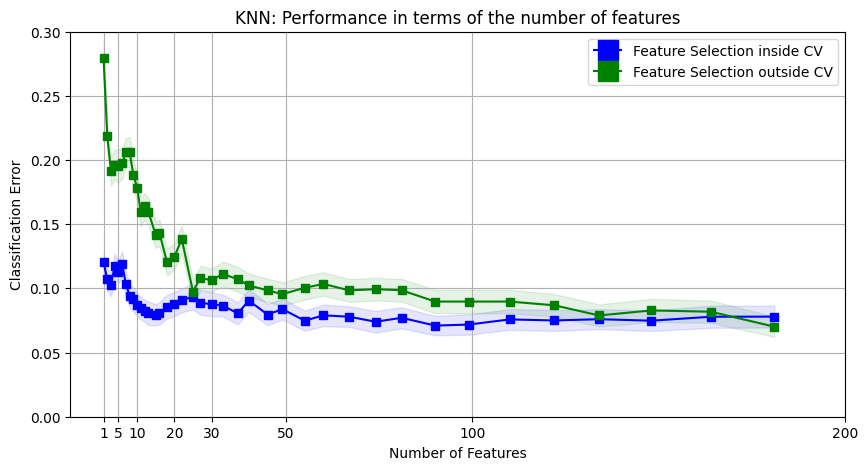

In [47]:
sel = np.arange(1, len(n_features) + 1, 8) - 1

plt.figure(figsize=(10,5))
line1, = plt.plot(n_features, error, 's-', color="b")
line3, = plt.plot(n_features, error_external, 's-', color="g")

plt.fill_between(n_features, error - error_std, error + error_std, alpha=0.1, color="b")
plt.fill_between(n_features, error_external - error_external_std, error_external + error_external_std, alpha=0.1, color="g")

plt.grid()
plt.title("KNN: Performance in terms of the number of features")
plt.xlabel('Number of Features')
plt.xticks(np.array([1, 5, 10, 20, 30, 50, 100, 200]))
plt.ylabel('Classification Error')
plt.ylim(0.0, 0.3)

legend_handles = [
    mlines.Line2D([], [], color='b', marker='s', markersize=15, label='Feature Selection inside CV'),
    mlines.Line2D([], [], color='g', marker='s', markersize=15, label='Feature Selection outside CV')
]

plt.legend(handles=legend_handles, loc=1)
plt.show()

**3.** Are the two estimates obtained similar? What are their differences? If they are different try to explain why this is the case.

- We see that the error of both cases is very different at the beginning, being the attribute selection method inside the loop more precise than the method in which the attribute selection is outside the loop, but they become more and more similar the greater the number of attributes is chosen.

- This difference at the beggining is probably due to the fact that the feature selection inside the loop is done only in the training fold, respecting the rule that test data should never be used for model building (in order to obtain an unbiased estimate), whilst the feature selection done outside the loop, uses all the dataset and then features already selected are used in CV. The last method is biased positively, because information leaks from the test data. However the error rate is highter because overfitting causes a worse generalization. Since we have a high-dimensional dataset, overfitting is more notorious, specially when dealing with a low number of features.

**4.** By taking a look at these results, what is the optimal number of features to use in this dataset in terms of interpretability vs. prediction 
error?

- From the graphs we see that there is a local minimum at n_features = 15, which is the lowest error in the range 1-50. Thus, we should take this 
number as it is not very high having into account that we are talking about gene expression and that a lot of genes express at any given time.

**5.** Given the results obtained in this part of the practical, you are asked to indicate which particular features should be used for prediction 
on this dataset. Include a list with them. Take a look at the documentation of SelectKBest from scikit-learn to understand how to do this. Use 
all available data to provide such a list of features. 

- The list of best features are indicated in the output of the following code.

In [48]:
# We obtain the index of the selected attributes.
selected_indices = external_filtering.get_support(indices=True)

# We print the name of the columns corresponding to the previous index.
print("Selected attributes:", list(dataprostate.columns[selected_indices[1:16]]))

Selected attributes: ['103_at', '1081_at', '1120_at', '1121_g_at', '1135_at', '1230_g_at', '1251_g_at', '1290_g_at', '1513_at', '1521_at', '1591_s_at', '160023_at', '160029_at', '162_at', '1664_at']
